In [103]:
from matplotlib import colors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import math
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import json

path_optical_6809 = 'C:/Users/HP/Desktop/Programación/Workspace/Python/Astronomy/NGC 6809/NGC6809.txt'

distance_parsecs = 5400
Mag_min = -50  # 0
Mag_max = 50   # 35
RMS_max = 1     # 0.1 #No quiero que aparezcan varias estrellas dentro del circulo, pues si eso sucede de todas formas no será posible dar un valor correcto
Fit_max = 1.5   # También puede ser 0.6, pero en en los filtros 606 y 814 no se pueden usar valores tan estrictos, pues se eliminarían demasiados puntos
Sharp_min = -2  # -0.25
Sharp_max = 2   # 0.25
CM_min = 80

bins_division = 20
min_count = 2
min_step = 2

bluer_limit = 0.5
significantly_bluer_limit = 1.0
redder_limit = 0.5
significantly_redder_limit = 1.0


optical_data = pd.read_csv(
    path_optical_6809,
    sep=r"\s+",      # split by any amount of whitespace
    header=None      # because there are no column names
)
optical_data.columns = [
        "X", "Y",
        "275_Mag", "275_RMS", "275_Fit", "275_Sharp", "275_exp_found", "275_exp_well",
        "336_Mag", "336_RMS", "336_Fit", "336_Sharp", "336_exp_found", "336_exp_well",
        "438_Mag", "438_RMS", "438_Fit", "438_Sharp", "438_exp_found", "438_exp_well",
        "606_Mag", "606_RMS", "606_Fit", "606_Sharp", "606_exp_found", "606_exp_well",
        "814_Mag", "814_RMS", "814_Fit", "814_Sharp", "814_exp_found", "814_exp_well",
        "Cluster_Membership",
        "RA", "Decl",
        "Id",
        "Iteration_found"
]


optical_data["Visible"] = (optical_data["438_Mag"]+optical_data["606_Mag"])/2

optical_data["Mv"] = optical_data["Visible"]-5*(math.log(distance_parsecs/10,10))

bands = ["275", "336", "438", "606", "814"]
mask = np.ones(len(optical_data), dtype=bool)
for b in bands:
    mask &= optical_data[f"{b}_Mag"].between(Mag_min, Mag_max)
    mask &= optical_data[f"{b}_RMS"] < RMS_max
    mask &= optical_data[f"{b}_Fit"] < Fit_max
    mask &= optical_data[f"{b}_Sharp"].between(Sharp_min, Sharp_max)
    mask &= optical_data["Cluster_Membership"] > CM_min


optical_data_filtered = optical_data[mask].copy()
optical_data_filtered.reset_index(inplace = True)
column_drop = ["X", "Y", "Iteration_found", "index"]
for i in bands:
    column_drop.append(i+"_RMS")
    column_drop.append(i+"_Fit")
    column_drop.append(i+"_Sharp")
    column_drop.append(i+"_exp_found")
    column_drop.append(i+"_exp_well")
optical_data_filtered.drop(columns = column_drop, inplace = True)

optical_data_filtered.sort_index(inplace = True)
optical_data_filtered['275 - 336'] = optical_data_filtered["275_Mag"] - optical_data_filtered["336_Mag"]
optical_data_filtered['438 - 606'] = optical_data_filtered["438_Mag"] - optical_data_filtered["606_Mag"]
optical_data_filtered['606 - 814'] = optical_data_filtered["606_Mag"] - optical_data_filtered["814_Mag"]
optical_data_filtered

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,23.0362,21.5343,21.5414,20.4450,19.6733,96.5,294.991260,-30.936518,R0045252,20.99320,7.331231,1.5019,1.0964,0.7717
11586,19.7004,19.0157,19.4706,18.6382,18.0522,97.7,294.997340,-30.935677,R0045267,19.05440,5.392431,0.6847,0.8324,0.5860
11587,25.0711,22.7921,22.4562,20.9407,20.1081,95.8,294.996743,-30.936112,R0045268,21.69845,8.036481,2.2790,1.5155,0.8326
11588,20.7275,19.9519,20.1673,19.3836,18.7379,95.2,294.992073,-30.935783,R0045299,19.77545,6.113481,0.7756,0.7837,0.6457


In [104]:
gráfico_comp = 2
#for gráfico_comp in range(3):
if gráfico_comp == 0: #F275W-F336W
    Color1 = "275"
    Color2 = "336"
elif gráfico_comp == 1: #F438W-F606W
    Color1 = "438"
    Color2 = "606"
elif gráfico_comp == 2: #F606W-F814W
    Color1 = "606"
    Color2 = "814"

#Def (optical_data_filtered, bins_division, S_dif, S_Color2)

S_Color2 = optical_data_filtered[Color2+"_Mag"]
S_dif = optical_data_filtered[f"{Color1} - {Color2}"]


#We define limits for the histogram, they have to be integer.
xmax = round(S_dif.max()+1)
xmin = round(S_dif.min()-1)
ymax = round(S_Color2.max()+1)
ymin = round(S_Color2.min()-1)

bins_xy = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
range_xy = [[xmin, xmax], [ymin, ymax]]

H, x_edges, y_edges = np.histogram2d(S_dif, S_Color2, bins = bins_xy, range = range_xy)

for i in range(len(H)):
    for j in range(len(H[0])):
        if H[i][j] < min_count:
            H[i][j] = 0

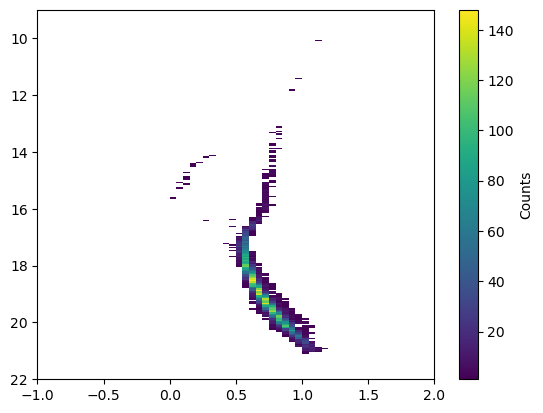

In [105]:
cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)
plt.gca().invert_yaxis()

plt.colorbar(label='Counts')
plt.show()

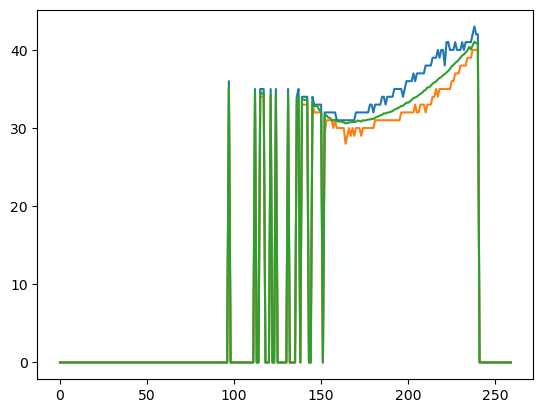

In [106]:
    mean_MS = []       # mean
    min_MS = []     # min
    max_MS = []     # max
    for i in H.T:
        #First we go for every bin to find the position of the bins with stars, and we save the count of consecutive
        # bins with stars (ou) and the count of consecutive bins without stars (n).
        indexes_MS = []
        values_MS = []

        stored_indexes = []
        stored_values = []
        insured_indexes = []
        insured_values = []

        insured_width = 0
        width_MS = 0
        max_width_found = 0
        count_empty_bins = 0
        for j,z in enumerate(i):
            #We consider that a bin has stars if its count is greater than 0, and we save the position and count of the 
            # bins with stars in k and kk, and we save the position and count of the last consecutive bins with stars in 
            # ku and kkuu.
            if z > 0:
                count_empty_bins = 0
                width_MS += 1
                stored_indexes.append(j)     #position
                stored_values.append(z)    #value
                insured_indexes = []
                insured_values = []
                insured_width = 0
            else:
                count_empty_bins += 1
                if count_empty_bins < 2:
                    #The previus values are saved
                    insured_indexes = stored_indexes.copy()
                    insured_values = stored_values.copy()
                    insured_width = width_MS
                    #The new values are updated
                    width_MS += 1
                    stored_indexes.append(j)     #position
                    stored_values.append(z)    #value
                else:
                    if insured_width > max_width_found and insured_width >= min_step:
                        values_MS = insured_values
                        indexes_MS = insured_indexes
                        max_width_found = insured_width
                    stored_values = []
                    stored_indexes = []
                    width_MS = 0
                    insured_indexes = []
                    insured_values = []
                    insured_width = 0
        #We save the position of the left and right limits of the main sequence. If there are no stars in any bin, 
        # we save 0 as the limits.
        if len(indexes_MS)>0:
            min_MS.append(indexes_MS[0])
            max_MS.append(indexes_MS[-1])
        else:
            min_MS.append(0)
            max_MS.append(0)
        total = 0
        #We also save the mean position of the bins with stars to plot the mean line of the main sequence.
        if len(indexes_MS) > 0:
            for j in range(len(indexes_MS)):
                total += indexes_MS[j]*values_MS[j]
            mean_MS.append(total/sum(values_MS))
        else:
            mean_MS.append(0)

plt.plot(max_MS)
plt.plot(min_MS)
plt.plot(mean_MS)
plt.show()

In [107]:
non_zero_values_indexes = []
for i,j in enumerate(mean_MS):
    if j == 0:
        non_zero_values_indexes.append(i)
non_zero_values_indexes

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 113,
 114,
 118,
 119,
 120,
 122,
 123,
 125,
 126,
 127,
 128,
 129,
 130,
 132,
 133,
 134,
 135,
 138,
 143,
 144,
 151,
 241,
 242,
 243,
 244,
 245,
 246,
 247,
 248,
 249,
 250,
 251,
 252,
 253,
 254,
 255,
 256,
 257,
 258,
 259]

In [108]:
chain_width = 0  
maximum_width = 0
# Searching for the maximum separation between bins with value 0
for i in range(len(non_zero_values_indexes)-1):
    index_difference = non_zero_values_indexes[i+1]-non_zero_values_indexes[i]-1
    if index_difference > maximum_width:
        maximum_width = index_difference
        chain_width = non_zero_values_indexes[i]
main_sequence = range(chain_width+1,chain_width+maximum_width)  #Getting the maximum chain of indexes that have 0 as a value

print(chain_width)
print(maximum_width)
print(main_sequence) 

151
89
range(152, 240)


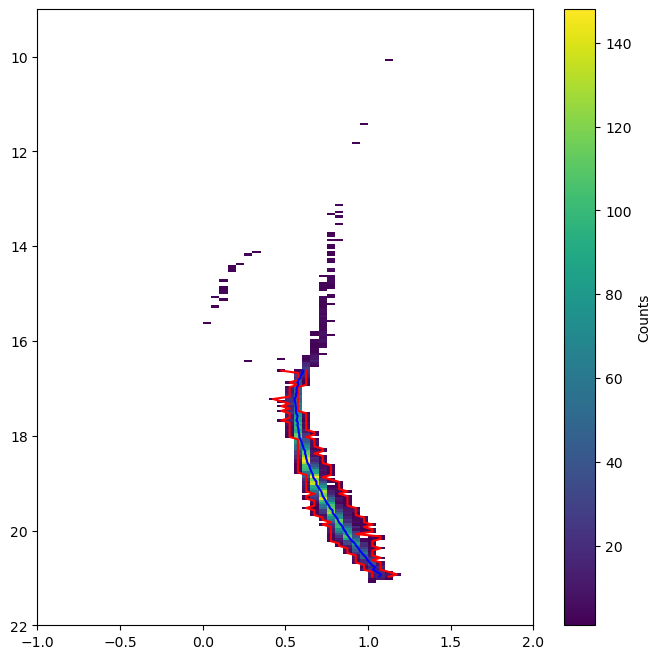

In [109]:
#Extract the positions (in cells) of the mean, max and min of the main sequence to plot them later. 
filtered_x = [x[i] for i in main_sequence]
filtered_max = [max[i] for i in main_sequence]
filtered_min = [min[i] for i in main_sequence]

#Change the positions from cells to magnitude values of the CMD
normalized_min = (np.array(filtered_min)/bins_division)+xmin+1/(2*bins_division)
normalized_max = (np.array(filtered_max)/bins_division)+xmin+1/(2*bins_division)
normalized_x = (np.array(filtered_x)/bins_division)+xmin+1/(2*bins_division)

main_sequence_y_magnitude = np.array(main_sequence)/bins_division+ymin+1/(2*bins_division)

plt.figure(figsize = (8, 8))
plt.plot(normalized_min, main_sequence_y_magnitude, c = "red")
plt.plot(normalized_max, main_sequence_y_magnitude, c = "red")
plt.plot(normalized_x, main_sequence_y_magnitude, c = "blue")
cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)
plt.colorbar(label='Counts')

plt.gca().invert_yaxis()

plt.show()

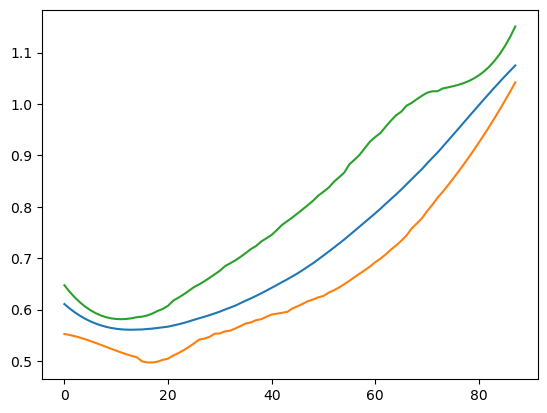

In [110]:
#Smooth the lines of the minimum and maximum of the main sequence using the Savitzky-Golay filter.
window_size = int(len(normalized_min)/3)
poly_order = 3
min_smooth = savgol_filter(normalized_min, window_size, poly_order)
max_smooth = savgol_filter(normalized_max, window_size, poly_order)
x_smooth = savgol_filter(normalized_x, window_size, poly_order)


plt.plot(x_smooth)
plt.plot(min_smooth)
plt.plot(max_smooth)
plt.show()

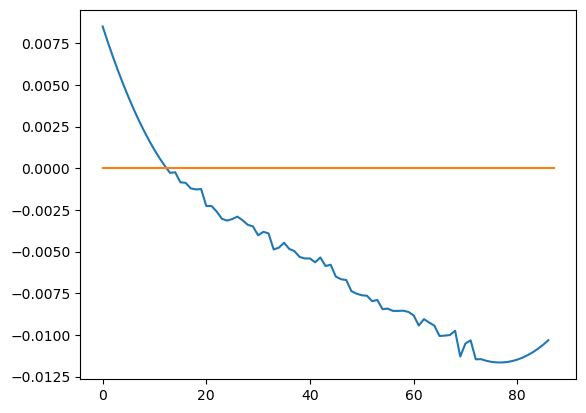

In [111]:
#We obtain the position of the start of the main sequence turn off.
derivative_x = []
for i in range(len(x_smooth)-1):
    derivative_x.append(x_smooth[i]-x_smooth[i+1])
plt.plot(derivative_x)
plt.plot(np.linspace(0, len(derivative_x), 2), [0,0])
plt.show()

In [112]:
container_d = []
for i,j in enumerate(derivative_x):
    if j <= 0:
        container_d.append(i)
if derivative_x[0] > 0 and 0 not in container_d:
    container_d.insert(0, -1)
container_d

[-1,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86]

In [113]:
chain_width_d = 0
maximum_d = 0
for i in range(len(container_d)-1):
    m_d = container_d[i+1]-container_d[i]-1
    if m_d > maximum_d:
        maximum_d = m_d
        chain_width_d = container_d[i]
msto_start = chain_width_d+maximum_d + chain_width + 1
msto_start_y_magnitude = msto_start/bins_division+ymin+1/(2*bins_division)

print(chain_width_d)
print(maximum_d)
print(msto_start)
print(msto_start_y_magnitude)

-1
13
164
17.224999999999998


In [114]:
np.where(main_sequence_y_magnitude == msto_start_y_magnitude)

(array([12]),)

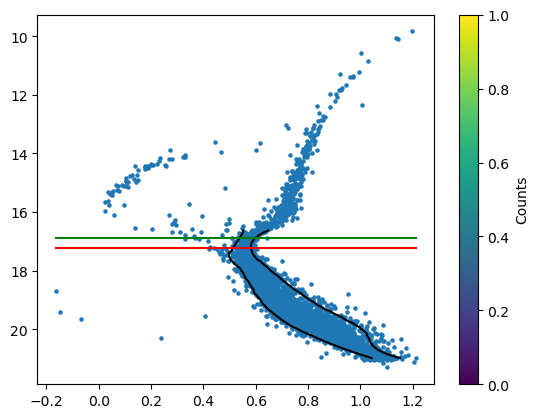

In [115]:
maximum_lenght_MSTO = 0.70 # The height of the MSTO and SGB can't be greater than 0.70.
maximum_lenght_index_MSTO = int(maximum_lenght_MSTO * bins_division)
half_lenght_index_MSTO = int(maximum_lenght_index_MSTO/2)

index_MSTO_y_start = np.where(main_sequence_y_magnitude == msto_start_y_magnitude)[0][0]
if index_MSTO_y_start < half_lenght_index_MSTO:
    index_SGB_y_start = 0
else:
    index_SGB_y_start = index_MSTO_y_start-half_lenght_index_MSTO

if index_MSTO_y_start > maximum_lenght_index_MSTO: 
    diference = index_MSTO_y_start - maximum_lenght_index_MSTO
    main_sequence_y_magnitude = np.delete(main_sequence_y_magnitude, range(diference))
    min_smooth = np.delete(min_smooth, range(diference))
    max_smooth = np.delete(max_smooth, range(diference))
    index_MSTO_y_start = index_MSTO_y_start - diference
    index_SGB_y_start = index_SGB_y_start - diference
    
    

plt.scatter(S_dif, S_Color2, s = 5)
plt.plot(min_smooth, main_sequence_y_magnitude, c = "black")
plt.plot(max_smooth, main_sequence_y_magnitude, c = "black")
plt.plot([S_dif.min(), S_dif.max()], [main_sequence_y_magnitude[index_MSTO_y_start], main_sequence_y_magnitude[index_MSTO_y_start]], c = "red")
plt.plot([S_dif.min(), S_dif.max()], [main_sequence_y_magnitude[index_SGB_y_start], main_sequence_y_magnitude[index_SGB_y_start]], c = "green")

plt.colorbar(label='Counts')

plt.gca().invert_yaxis()
plt.show()

In [116]:
point_G = [max_smooth[np.where(msto_start_y_magnitude == main_sequence_y_magnitude)[0][0]], msto_start_y_magnitude]
point_H = [min_smooth[np.where(msto_start_y_magnitude == main_sequence_y_magnitude)[0][0]], msto_start_y_magnitude]
print(point_G)
print(point_H)

[np.float64(0.5816895570441176), 17.224999999999998]
[np.float64(0.5128409703632174), 17.224999999999998]


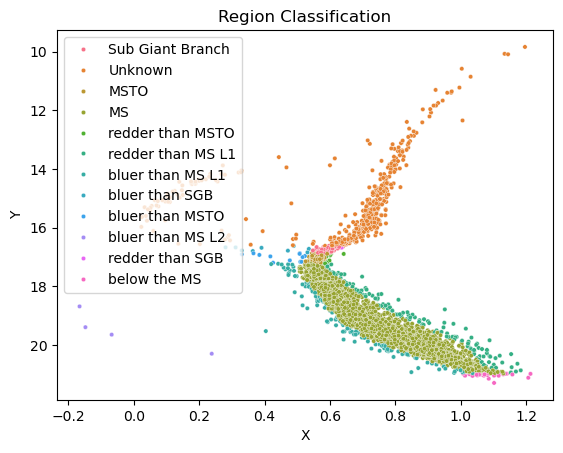

In [117]:
optical_data_filtered[f"position_{gráfico_comp}"] = "Unknown"

df = optical_data_filtered

y_col = Color2 + "_Mag"
x_col = f"{Color1} - {Color2}"
pos_col = f"position_{gráfico_comp}"

y_vals = df[y_col].values
x_vals = df[x_col].values

# Initialize column once

for i in range(len(main_sequence_y_magnitude) - 1):
    xmin_1, xmin_2 = min_smooth[i], min_smooth[i+1]
    xmax_1, xmax_2 = max_smooth[i], max_smooth[i+1]
    y_1, y_2 = main_sequence_y_magnitude[i], main_sequence_y_magnitude[i+1]

    slope = (xmin_2 - xmin_1) / (y_2 - y_1)

    # Mask for this segment (vectorized)
    mask = (y_vals >= y_1) & (y_vals < y_2)

    if not mask.any():
        continue

    y_seg = y_vals[mask]
    x_seg = x_vals[mask]

    x_min_real = xmin_1 + (y_seg - y_1) * slope
    x_max_real = xmax_1 + (y_seg - y_1) * slope

    # Classification (vectorized)
    if i <= index_SGB_y_start - 1:
        labels = np.select(
            [
                x_seg < x_min_real - significantly_bluer_limit,
                x_seg < x_min_real - bluer_limit,
                x_seg < x_min_real,
                x_seg < x_max_real,
                x_seg < x_max_real + redder_limit,
                x_seg < x_max_real + significantly_redder_limit,
            ],
            [
                "bluer than MS L3",
                "bluer than MS L2",
                "bluer than SGB",
                "Sub Giant Branch",
                "redder than SGB",
                "redder than MS L2",
            ],
            default="redder than MS L3",
        )

    elif i <= index_MSTO_y_start - 1:
        labels = np.select(
            [
                x_seg < x_min_real - significantly_bluer_limit,
                x_seg < x_min_real - bluer_limit,
                x_seg < x_min_real,
                x_seg < x_max_real,
                x_seg < x_max_real + redder_limit,
                x_seg < x_max_real + significantly_redder_limit,
            ],
            [
                "bluer than MS L3",
                "bluer than MS L2",
                "bluer than MSTO",
                "MSTO",
                "redder than MSTO",
                "redder than MS L2",
            ],
            default="redder than MS L3",
        )

    else:
        labels = np.select(
            [
                x_seg < x_min_real - significantly_bluer_limit,
                x_seg < x_min_real - bluer_limit,
                x_seg < x_min_real,
                x_seg < x_max_real,
                x_seg < x_max_real + redder_limit,
                x_seg < x_max_real + significantly_redder_limit,
            ],
            [
                "bluer than MS L3",
                "bluer than MS L2",
                "bluer than MS L1",
                "MS",
                "redder than MS L1",
                "redder than MS L2",
            ],
            default="redder than MS L3",
        )

    df.loc[mask, pos_col] = labels

# Handle below MS (vectorized)
df.loc[y_vals > main_sequence_y_magnitude[-1], pos_col] = "below the MS"

sns.scatterplot(data = df, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{gráfico_comp}", s = 10)
plt.gca().invert_yaxis()


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
plt.legend()

plt.show()


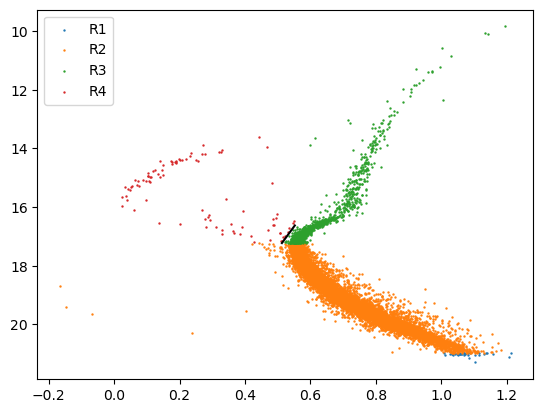

In [118]:
# --- Precompute once ---
y_vals = main_sequence_y_magnitude
idx_A = np.argmax(y_vals == msto_start_y_magnitude)  # faster than np.where()[0][0]

x_A = min_smooth[idx_A]
y_A = msto_start_y_magnitude

x_B = min_smooth[0]
y_B = y_vals[0]

Min_MS = y_vals[-1]

slope_m = (x_B - x_A) / (y_B - y_A)

# Column names
x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{gráfico_comp}"

# --- Work directly on arrays (FASTER) ---
df = optical_data_filtered
x = df[x_col].values
y = df[y_col].values
pos = df[pos_col].values

# Precompute line (vectorized)
line = x_A + slope_m * (y - y_A)

# --- Masks (no copies yet) ---
mask_r1 = y >= Min_MS

mask_r2 = (y < Min_MS) & (y >= y_A)

mask_common_upper = (y < y_A) & (y >= y_B)
mask_lower = y < y_B

mask_sgb_msto = (pos == "Sub Giant Branch") | (pos == "MSTO")

mask_r3 = (
    (mask_common_upper & (x > line)) |
    (mask_lower & (x > x_B)) |
    mask_sgb_msto
)

mask_r4 = (
    ((mask_common_upper & (x <= line)) |
     (mask_lower & (x <= x_B))) &
    (~mask_sgb_msto)
)

# --- Only now create DataFrames (if needed) ---
region1 = df[mask_r1]
region2 = df[mask_r2]
region3 = df[mask_r3]
region4 = df[mask_r4]

plt.scatter(region1[x_col], region1[y_col], s=0.5, label='R1')
plt.scatter(region2[x_col], region2[y_col], s=0.5, label='R2')
plt.scatter(region3[x_col], region3[y_col], s=0.5, label='R3')
plt.scatter(region4[x_col], region4[y_col], s=0.5, label='R4')
plt.plot([x_A, x_B], [y_A, y_B], c = "black")

plt.gca().invert_yaxis()
plt.legend()
plt.show()

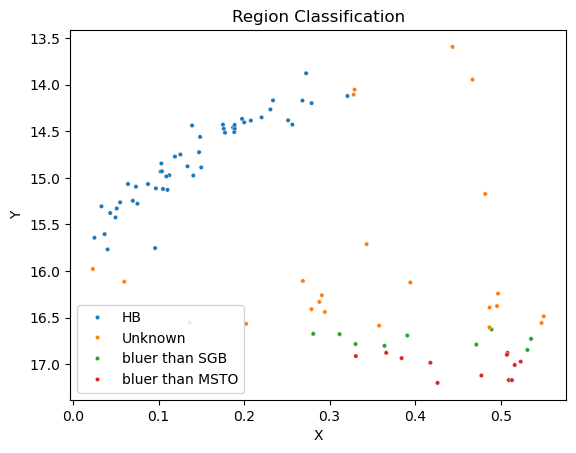

In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt



x = region4[f"{Color1} - {Color2}"]
y = region4[f"{Color2}_Mag"]

X = np.column_stack((x, y))

# Normalize
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=15).fit(X_scaled)
labels = db.labels_

unique_labels = set(labels)



# --- Extract clusters (ignore noise) ---
clusters = [label for label in unique_labels if label != -1]

# --- Case 1: Only one cluster ---
if len(clusters) == 1:
    selected_label = clusters[0]

# --- Case 2: More than one cluster ---
else:
    best_label = None
    best_score = None

    for label in clusters:
        mask = labels == label
        
        x_mean = np.mean(x[mask])
        y_mean = np.mean(y[mask])
        
        # We want TOP-LEFT:
        # smaller x → more left
        # smaller y → brighter (top in CMD)
        score = 2*x_mean + y_mean  # minimize this
        
        if best_score is None or score < best_score:
            best_score = score
            best_label = label

    selected_label = best_label



# --- Extract coordinates of selected cluster ---
mask = labels == selected_label

x_selected = x[mask].values
y_selected = y[mask].values

point_C = [x_selected.min(), y_selected.max()]
point_D = [x_selected.max(), y_selected.min()]
point_E = [x_selected.max(), y_selected.max()]
for i,j in enumerate(region4.index):
    if labels[i] == selected_label:
        region4.loc[j,f"position_{gráfico_comp}"] = "HB"

        
sns.scatterplot(data = region4, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{gráfico_comp}", s = 10)
plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
plt.legend()

plt.show()

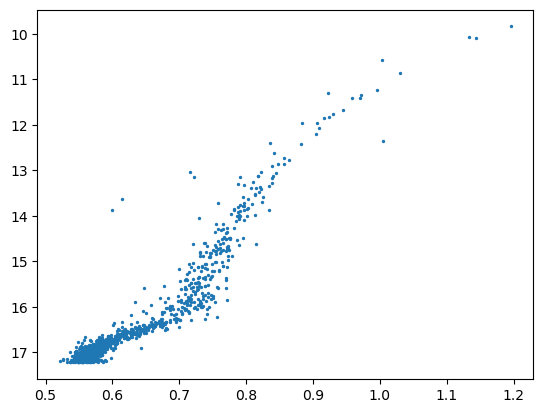

In [120]:
x = region3[f"{Color1} - {Color2}"]
y = region3[f"{Color2}_Mag"]
plt.scatter(x,y, s = 2)
plt.gca().invert_yaxis()
plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

x = region3[f"{Color1} - {Color2}"]
y = region3[f"{Color2}_Mag"]

X = np.column_stack((x, y))

# Normalize
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.4, min_samples=15).fit(X_scaled)
labels = db.labels_

unique_labels = set(labels)

# --- Extract clusters (ignore noise) ---
clusters = [label for label in unique_labels if label != -1]

# --- Case 1: Only one cluster ---
if len(clusters) == 1:
    selected_label = clusters[0]

# --- Case 2: More than one cluster ---
else:
    best_label = None
    best_score = None

    for label in clusters:
        mask = labels == label
        
        x_mean = np.mean(x[mask])
        y_mean = np.mean(y[mask])
        
        # We want BOT-LEFT:
        # smaller x → more left
        # bigger y → less brighter (BOT in CMD)
        score = x_mean - y_mean  # minimize this
        
        if best_score is None or score < best_score:
            best_score = score
            best_label = label

    selected_label = best_label



# --- Extract coordinates of selected cluster ---
mask = labels == selected_label

x_selected = x[mask].values
y_selected = y[mask].values

F = [x_selected.max(), y_selected.min()]

region3.loc[(labels == selected_label) & (region3[f"position_{gráfico_comp}"] == "Unknown"), f"position_{gráfico_comp}"] = "RGB"

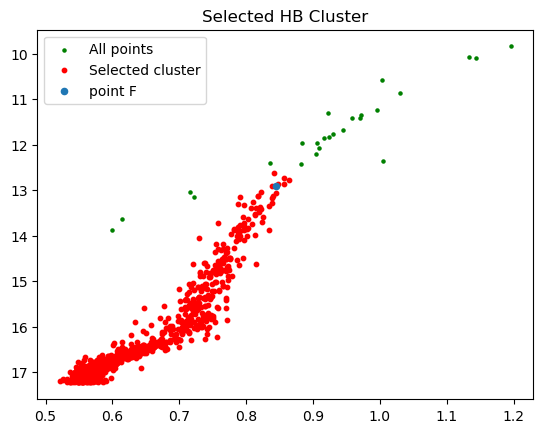

In [135]:
plt.scatter(x, y, c="green", s=5, label="All points")
plt.scatter(x_selected, y_selected, c="red", s=10, label="Selected cluster")
plt.scatter(point_F[0], point_F[1],  s=20, label="point F")


plt.gca().invert_yaxis()
plt.legend()
plt.title("Selected HB Cluster")
plt.show()

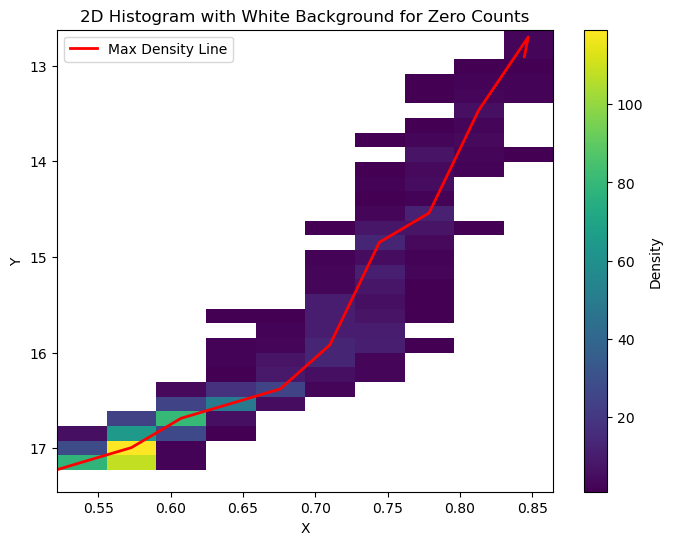

In [136]:
import numpy as np
import matplotlib.pyplot as plt
xmax = round(x_selected.max()+1)
xmin = round(x_selected.min()-1)
ymax = round(y_selected.max()+1)
ymin = round(y_selected.min()-1)

bins_xy = [int(bins_division*(xmax-xmin)/4), int(bins_division*(ymax-ymin)/4)]

H, xedges, yedges = np.histogram2d(x_selected, y_selected, bins = bins_xy)
H = H.T

# Mask zeros → they won't be plotted
H_masked = np.ma.masked_where(H == 0, H)

# Copy colormap and set masked values to white
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')

# Bin centers
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

# Ridge extraction (same as before)
ridge_x, ridge_y = [], []

for i in range(len(x_centers)):
    column = H[:, i]
    
    if np.sum(column) == 0:
        continue
    
    max_idx = np.argmax(column)
    ridge_x.append(x_centers[i])
    ridge_y.append(y_centers[max_idx])

ridge_x = np.array(ridge_x)
ridge_y = np.array(ridge_y)

# ---- Plot ----
plt.figure(figsize=(8, 6))

plt.imshow(
    H_masked,
    origin='lower',
    aspect='auto',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap=cmap
)

plt.colorbar(label='Density')
ridge_complete_x = np.concatenate(([x_selected.min()], ridge_x, [point_F[0]]))
ridge_complete_y = np.concatenate(([msto_start_y_magnitude], ridge_y, [point_F[1]]))
plt.plot(ridge_complete_x, ridge_complete_y, color='red', linewidth=2, label='Max Density Line')
plt.gca().invert_yaxis()

plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram with White Background for Zero Counts')
plt.legend()

plt.show()

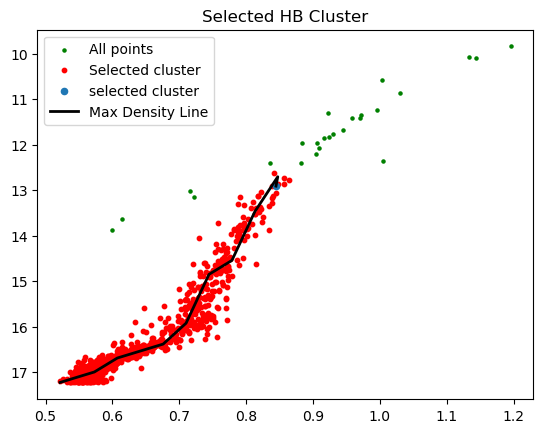

In [137]:
plt.scatter(x, y, c="green", s=5, label="All points")
plt.scatter(x_selected, y_selected, c="red", s=10, label="Selected cluster")
plt.scatter(point_F[0], point_F[1],  s=20, label="selected cluster")
plt.plot(ridge_complete_x, ridge_complete_y, color='black', linewidth=2, label='Max Density Line')


plt.gca().invert_yaxis()
plt.legend()
plt.title("Selected HB Cluster")
plt.show()

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# df has: df["x"], df["y"]
x = region3[f"{Color1} - {Color2}"]
y = region3[f"{Color2}_Mag"]

# ---------------------------
# 1. Compute 2D histogram
# ---------------------------
bins = 20
H, xedges, yedges = np.histogram2d(x, y, bins=bins)
H = H.T

x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

# ---------------------------
# 2. Extract ridge line
# ---------------------------
ridge_x, ridge_y = [], []

for i in range(len(x_centers)):
    column = H[:, i]
    
    if not np.any(column):  # skip empty columns
        continue
    
    max_idx = np.argmax(column)
    
    ridge_x.append(x_centers[i])
    ridge_y.append(y_centers[max_idx])

ridge_x = np.array(ridge_x)
ridge_y = np.array(ridge_y)

# ---------------------------
# 3. Interpolate ridge
# ---------------------------
ridge_func = interp1d(
    ridge_x, ridge_y,
    kind='linear',
    bounds_error=False,
    fill_value="extrapolate"
)
# ---------------------------
# 4. Define vertical boundary
# ---------------------------
x_cut = point_F[0]  # <-- YOU set this value

# ---------------------------
# 5. Classify points
# ---------------------------
pos = []

for xi, yi in zip(x, y):
    
    if xi > x_cut:
        pos.append("Red Super Giant Branch")
    else:
        y_ridge = ridge_func(xi)
        
        if yi > y_ridge:
            pos.append("Red Straggler")
        else:
            pos.append("Unknown")
for i,j in enumerate(region3.index):
    if region3.loc[j,f"position_{gráfico_comp}"] == "Unknown":
        region3.loc[j,f"position_{gráfico_comp}"] = pos[i]
    if region3.loc[j,f"position_{gráfico_comp}"] == "redder than MSTO" or region3.loc[j,f"position_{gráfico_comp}"] == "bluer than MSTO":
        region3.loc[j,f"position_{gráfico_comp}"] = "MSTO"
    if region3.loc[j,f"position_{gráfico_comp}"] == "redder than SGB" or region3.loc[j,f"position_{gráfico_comp}"] == "bluer than SGB":
        region3.loc[j,f"position_{gráfico_comp}"] = "Sub Giant Branch"


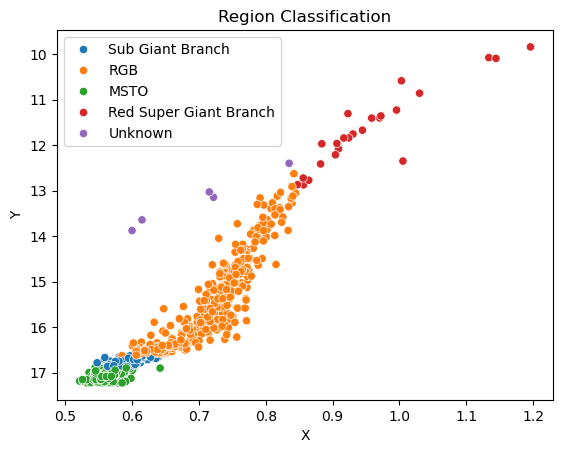

In [139]:
x = region3[f"{Color1} - {Color2}"]
y = region3[f"{Color2}_Mag"]
sns.scatterplot(data = region3, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{gráfico_comp}")
plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
plt.legend()

plt.show()

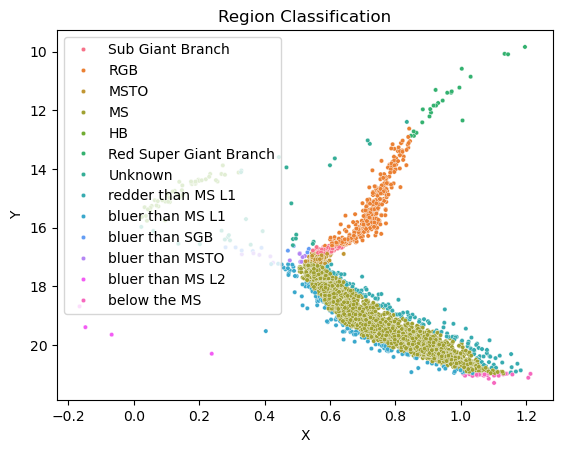

In [140]:
df_merged = pd.concat([region1, region2, region3, region4]).sort_index()
df_merged

for i,j in enumerate(df_merged.index):
    if df_merged.loc[j,f"position_{gráfico_comp}"] == "redder than SGB" or df_merged.loc[j,f"position_{gráfico_comp}"] == "redder than MSTO":
        df_merged.loc[j,f"position_{gráfico_comp}"] = "Sub-Sub-Giant Branch"

sns.scatterplot(data = df_merged, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{gráfico_comp}", s = 10)
plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
plt.legend()

plt.show()

In [141]:
from matplotlib.path import Path
import numpy as np

polygon = np.array([
    [point_C[0], point_C[1]],
    [point_D[0], point_D[1]],
    [point_G[0], point_G[1]],
    [point_H[0], point_H[1]]
])

poly_path = Path(polygon)

points = np.column_stack((
    df_merged[f"{Color1} - {Color2}"],
    df_merged[f"{Color2}_Mag"]
))

inside = poly_path.contains_points(points)

for i in df_merged.index:
    if ((df_merged.loc[i, f"position_{gráfico_comp}"] == "Unknown") or (df_merged.loc[i, f"position_{gráfico_comp}"] == "bluer than SGB") or (df_merged.loc[i, f"position_{gráfico_comp}"] == "bluer than MS L2")) and (inside[i] == True) or (df_merged.loc[i, f"position_{gráfico_comp}"] == "bluer than MSTO"): 
        df_merged.loc[i, f"position_{gráfico_comp}"] = "BS"

In [142]:
polygon = np.insert(polygon, 4, [point_C[0], point_C[1]], axis=0)

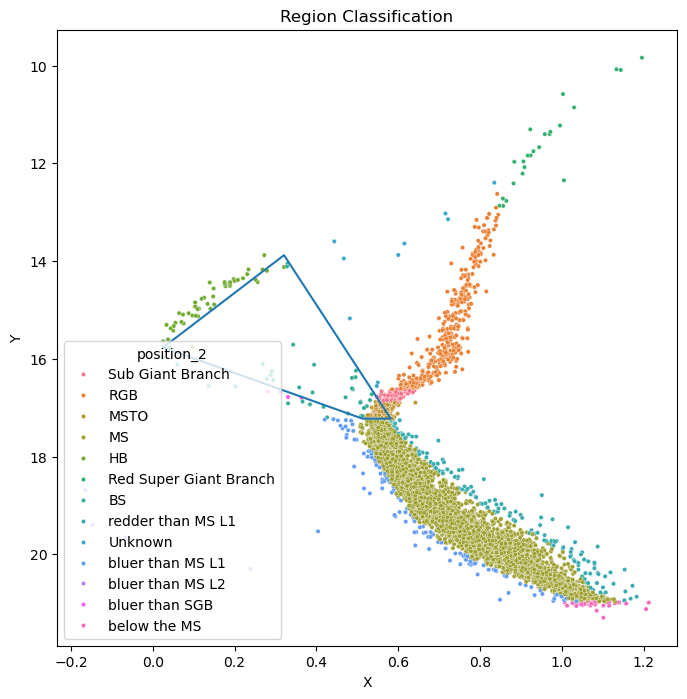

In [143]:
plt.figure(figsize = (8, 8))
sns.scatterplot(data = df_merged, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{gráfico_comp}", s = 10, legend = True)
plt.gca().invert_yaxis()
plt.plot(polygon[:,0], polygon[:,1])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
#plt.legend()
plt.show()

In [144]:
x_E = point_E[0]
y_E = point_E[1]
x_F = point_F[0]
y_F = point_F[1]

# Line EF
m = (y_F - y_E) / (x_F - x_E)
b = y_E - m * x_E

x_vals = df_merged[f"{Color1} - {Color2}"]
y_vals = df_merged[f"{Color2}_Mag"]
pos_vals = df_merged[f"position_{gráfico_comp}"]
# Condition: RIGHT of E and ABOVE the line
mask_agb = (x_vals > x_E) & (y_vals < (m * x_vals + b)) & (pos_vals == "Unknown")

df_merged.loc[mask_agb, f"position_{gráfico_comp}"] = "AGB"

In [145]:
np.append(polygon, np.array([[point_C[0], point_C[1]]]), axis = 0)


array([[ 0.0251    , 15.7667    ],
       [ 0.3208    , 13.8789    ],
       [ 0.58168956, 17.225     ],
       [ 0.51284097, 17.225     ],
       [ 0.0251    , 15.7667    ],
       [ 0.0251    , 15.7667    ]])

In [146]:
polygon

array([[ 0.0251    , 15.7667    ],
       [ 0.3208    , 13.8789    ],
       [ 0.58168956, 17.225     ],
       [ 0.51284097, 17.225     ],
       [ 0.0251    , 15.7667    ]])

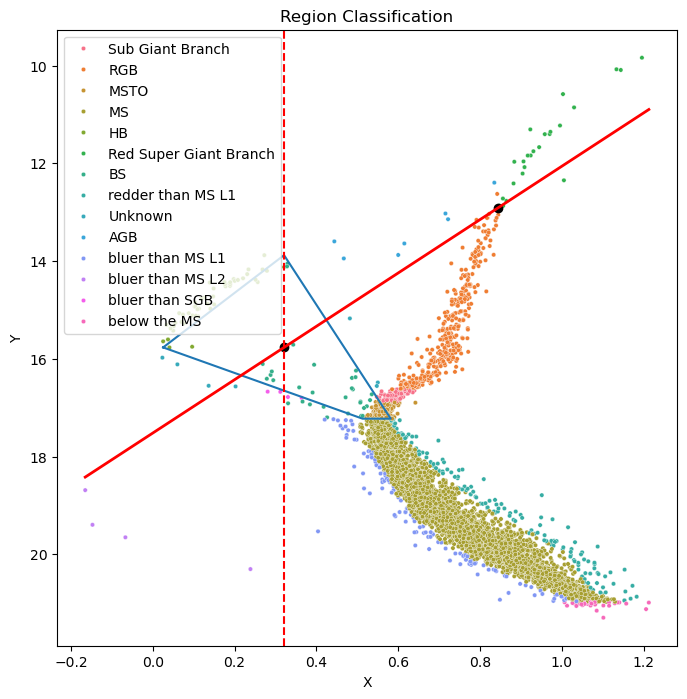

In [149]:
plt.figure(figsize = (8, 8))
sns.scatterplot(data = df_merged, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{gráfico_comp}", s = 10)
plt.gca().invert_yaxis()
plt.plot(polygon[:,0], polygon[:,1])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Region Classification")
plt.legend()
x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)
y_plot = m * x_plot + b

plt.plot(x_plot, y_plot, color='red', linewidth=2)
plt.axvline(x_E, color='red', linestyle='--')
plt.scatter([x_E, x_F], [y_E, y_F], color='black')
plt.show()